# HW 14 - Astropy
ULAB - Physics and Astronomy Division \
Due **Sunday, March 1st, 2025 at 11:59pm** on Gradescope

## 1 Unit Conversion
Import the astropy module `units` as `u` in the cell below.

In [2]:
import astropy.units as u

Convert a speed of **60 km/h** to **m/s**. \
\
Round your answer to two significant digits. *Hint: With an f-string, you can use `:.3f`, like `print(f"{speed_mps:.3f}")`*.

In [4]:
speed = 60 * u.km / u.hour
speed_mps = speed.to(u.m / u.s)
print(f"{speed_mps:.2f}")

16.67 m / s


## 2 Time Manipulation
Define **Julian Date** in the cell below.

In [6]:
from astropy.time import Time

# Get the current time as an astropy Time object and print the Julian Date
now = Time.now()
print(f"The current Julian Date is: {now.jd}")

The current Julian Date is: 2460735.7665594765


What's the difference between the **Julian calendar** and the **Gregorian calendar**?

In [8]:
**Difference between the Julian calendar and the Gregorian calendar:**

The **Julian calendar**, introduced by Julius Caesar in 46 BC, was designed to approximate the solar year. The calendar has a leap year every four years, making an average year length of 365.25 days. However, this system results in a gain of about three days every four centuries.

The **Gregorian calendar**, instituted by Pope Gregory XIII in 1582, modifies the Julian system to better align with the actual solar year and the equinoxes. This calendar refines the leap year rule by omitting three leap days every 400 years. In the Gregorian system, a year is a leap year if:
- It is divisible by 4, but,
- Years divisible by 100 are not leap years, unless,
- They are also divisible by 400.

This adjustment reduces the average year length to about 365.2425 days, which is very close to the solar year of approximately 365.2422 days. The Gregorian calendar is the most widely used civil calendar today.

SyntaxError: invalid syntax (2599733888.py, line 1)

From the astropy module `time` import `Time` in the cell below.

In [10]:
from astropy.time import Time

Find the Julian Date for **the current time**. 

In [12]:
from astropy.time import Time

current_time = Time.now()

print(f"The Julian Date for the current time is: {current_time.jd}")

The Julian Date for the current time is: 2460735.7699930742


Convert `1969-07-02 20:17:00` to its **Julian Date**.

In [14]:
from astropy.time import Time

specified_time = Time('1969-07-02 20:17:00')

print(f"The Julian Date for 1969-07-02 20:17:00 is: {specified_time.jd}")

The Julian Date for 1969-07-02 20:17:00 is: 2440405.345138889


What historically happened at this date and time?

In [16]:
# Apollo 11 Laucnh!!!

## 3 Coordinate Transformations
From the astropy module `coordinates` import `SkyCoord`, `Galactic`, `AltAz` and `EarthLocation` in the cell below.

In [18]:
from astropy.coordinates import SkyCoord, Galactic, AltAz, EarthLocation

Define a celestial object at **RA = 15 degrees** and **DEC = -20 degrees** in ICRS. Use the astropy `Time` module.

In [20]:
from astropy.coordinates import SkyCoord
from astropy.time import Time
import astropy.units as u

celestial_object = SkyCoord(ra=15*u.degree, dec=-20*u.degree, frame='icrs')

current_time = Time.now()

print(f"Celestial Object RA: {celestial_object.ra}, DEC: {celestial_object.dec}")

print(f"Current Time: {current_time.iso}")

Celestial Object RA: 15.0 deg, DEC: -20.0 deg
Current Time: 2025-03-01 06:36:57.699


Convert the object's coordinates from ICSRS to **Galactic**.

In [22]:
from astropy.coordinates import SkyCoord
import astropy.units as u

celestial_object_icrs = SkyCoord(ra=15*u.degree, dec=-20*u.degree, frame='icrs')

celestial_object_galactic = celestial_object_icrs.galactic

print(f"Galactic Longitude: {celestial_object_galactic.l}, Galactic Latitude: {celestial_object_galactic.b}")

Galactic Longitude: 138.7612378253739 deg, Galactic Latitude: -82.60718782325382 deg


Convert the object's coordinate from ICRS to **AltAz**. For AltAz frame, use the location of **Campbell Hall**.

In [26]:
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import astropy.units as u

celestial_object_icrs = SkyCoord(ra=15*u.degree, dec=-20*u.degree, frame='icrs')

campbell_hall_location = EarthLocation(lat=37.8732*u.deg, lon=-122.2573*u.deg, height=50*u.m)

observation_time = Time.now()

altaz_frame = AltAz(obstime=observation_time, location=campbell_hall_location)

celestial_object_altaz = celestial_object_icrs.transform_to(altaz_frame)

print(f"Altitude: {celestial_object_altaz.alt}, Azimuth: {celestial_object_altaz.az}")

Altitude: -36.96378751207084 deg, Azimuth: 272.6641229462416 deg


## 4 FITS Files
From the astropy module `astropy.io` import `fits` in the cell below.

In [28]:
from astropy.io import fits

From the astropy module `astropy.utils.data` import `download_file`.

In [30]:
from astropy.utils.data import download_file

Import `numpy` in the cell below.

In [32]:
import numpy as np

Use the `download_file` astropy function to create a variable for the location of the `.fits` file from class.

In [ ]:
image_file = download_file('http://data.astropy.org/tutorials/FITS-images/HorseHead.fits', cache=True)

Follow the procedure from lecture to open the `.fits` files in the cell below. Make sure to use the `hdul` format, while calling `hdul.info`, `hdul[0]` and `hdul[1]` appropriately.

In [34]:
from astropy.io import fits

image_file = download_file('http://data.astropy.org/tutorials/FITS-images/HorseHead.fits', cache=True)

hdul = fits.open(image_file)

hdul.info()

print("Primary HDU Header:")
print(hdul[0].header)

if len(hdul) > 1:
    print("\nSecondary HDU Header:")
    print(hdul[1].header)

Filename: C:\Users\03kes\.astropy\cache\download\url\ff6e0b93871033c68022ca026a956d87\contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   (891, 893)   int16   
  1  er.mask       1 TableHDU        25   1600R x 4C   [F6.2, F6.2, F6.2, F6.2]   
Primary HDU Header:
SIMPLE  =                    T /FITS: Compliance                                BITPIX  =                   16 /FITS: I*2 Data                                  NAXIS   =                    2 /FITS: 2-D Image Data                            NAXIS1  =                  891 /FITS: X Dimension                               NAXIS2  =                  893 /FITS: Y Dimension                               EXTEND  =                    T /FITS: File can contain extensions               DATE    = '2014-01-09        '  /FITS: Creation Date                            ORIGIN  = 'STScI/MAST'         /GSSS: STScI Digitized Sky Survey                SURVEY  = 'SERC-ER '           /GSSS

With the `np.max` function, find the brightest pixel in the image. Print its value in the cell below.

In [38]:
import numpy as np
from astropy.io import fits

image_file = download_file('http://data.astropy.org/tutorials/FITS-images/HorseHead.fits', cache=True)
hdul = fits.open(image_file)

image_data = hdul[0].data

brightest_pixel = np.max(image_data)
print(f"Brightest Pixel Value: {brightest_pixel}")

Brightest Pixel Value: 22918


With the `np.min` function, find the least brightest pixel in the image. Print its value in the cell below.

In [42]:
import numpy as np
from astropy.io import fits

image_file = download_file('http://data.astropy.org/tutorials/FITS-images/HorseHead.fits', cache=True)
hdul = fits.open(image_file)

image_data = hdul[0].data

darkest_pixel = np.min(image_data)
print(f"Least Bright Pixel Value: {darkest_pixel}")

Least Bright Pixel Value: 3759


## Tables
From the astropy module `astropy.table` import `Table`.

In [44]:
from astropy.table import Table

Make an astropy table with **three** actual stars (so you will need to use google for this part). Include the `name`, `magnitude` and `spectral type`.

In [46]:
from astropy.table import Table

# Define the data for the table
data = {'name': ['Sirius', 'Betelgeuse', 'Procyon'],
        'magnitude': [-1.46, 0.42, 0.34],
        'spectral type': ['A1V', 'M2Iab', 'F5IV-V']}

# Create the table
star_table = Table(data)

# Print the table
print(star_table)

   name    magnitude spectral type
---------- --------- -------------
    Sirius     -1.46           A1V
Betelgeuse      0.42         M2Iab
   Procyon      0.34        F5IV-V


Save the table as a `.fits` file. *Hint: Use the function `.write` with the argument `format='fits'`.*

In [48]:
from astropy.table import Table

# Define the data for the table
data = {'name': ['Sirius', 'Betelgeuse', 'Procyon'],
        'magnitude': [-1.46, 0.42, 0.34],
        'spectral type': ['A1V', 'M2Iab', 'F5IV-V']}

# Create the table
star_table = Table(data)

# Specify the filename for the FITS file
filename = 'stars_table.fits'

# Save the table to a FITS file
star_table.write(filename, format='fits', overwrite=True)

print(f"Table saved as {filename}.")

Table saved as stars_table.fits.


Read and print the table in the cell below from the `.fits` file you made.

In [50]:
from astropy.table import Table

# Specify the filename of the FITS file
filename = 'stars_table.fits'

# Read the table from the FITS file
star_table = Table.read(filename, format='fits')

# Print the table
print(star_table)

   name    magnitude spectral type
---------- --------- -------------
    Sirius     -1.46           A1V
Betelgeuse      0.42         M2Iab
   Procyon      0.34        F5IV-V


## 6 Advanced... but awesome!
With the Hipparcos catalog, construct a Hertzsprung-Russell (H-R) diagram. Overall you will do the following:
* Download and clean the stellar data from the Hipparcos catalog.
* Calculate the absolute magnitude of the stars.
* Convert and classify spectral types.
* Plot an H-R diagram using both spectral class and color-index (B-V).

In the cell below, define what an **H-R** diagram is.

In [52]:
# An H-R diagram is a scatter plot that astronomers use to illustrate the relationships and differences between stars. It is named after Ejnar Hertzsprung and Henry Norris Russell, who independently developed versions of this diagram in the early 20th century.

### 6.1 Download and Load in the Hipparcos Catalog
The catalog you are downloading contains accurate parallax measurements which will help us determine the **absolute magnitude** of stars. 
* **Absolute mangitude** = the actual brightness of a star
* **Apparent magnitude** = how bright the star appears to us on Earth

Import `pandas` in the cell below.

In [54]:
import pandas as pd

In the cell below import the file `cluster_data.csv` as a pandas dataframe. Add the following arguments:
* skiprows=44
* sep=';'
* header=None
* index_col=0
* names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType']
* skipfooter=1
* engine='python'

In [78]:
df = pd.read_csv('cluster_data.csv',
                 skiprows=44, sep=';', 
                 header=None, index_col=0, 
                 names=['HIP', 'Vmag', 'Plx', 'B-V', 'SpType'],
                 skipfooter=1, engine='python'
                )

Display the first few rows of the data.

In [80]:
print(df.head())

      Vmag      Plx     B-V SpType
HIP                               
10    8.59    10.76   0.489    F6V
11    7.34     4.29   0.081     A2
12    8.43     4.06   1.484  K4III
13    8.80     3.49   1.128  K0III
14    7.25     5.11   1.200     K0


### 6.2 Clean the Data
Some of the rows in the data contain **missing** or **invalid** values so we need to "clean" our data. We will start by replacing the **blank spaces with NaN**, run the cell below.

In [96]:
import pandas as pd
import numpy as np

df_clean = df.applymap(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)

print(df_clean.head())

      Vmag      Plx     B-V SpType
HIP                               
10    8.59    10.76   0.489    F6V
11    7.34     4.29   0.081     A2
12    8.43     4.06   1.484  K4III
13    8.80     3.49   1.128  K0III
14    7.25     5.11   1.200     K0


C:\Users\03kes\AppData\Local\Temp\ipykernel_13348\3687310234.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df.applymap(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)


Drop the rows with missing (NaN) values. *Hint: Use the `.dropna()` function`.

In [99]:
df_clean = df_clean.dropna()

Run the cell below. We are converting the datatypes in the columns to floats.

In [101]:
df_clean[['Vmag', 'Plx', 'B-V']] = df_clean[['Vmag', 'Plx', 'B-V']].astype(float)

# Display dataset summary
print(df_clean.describe())

                Vmag            Plx            B-V
count  114463.000000  114463.000000  114463.000000
mean        8.297699       7.104872       0.702415
std         1.248614      11.064009       0.490235
min        -1.440000     -35.100000      -0.400000
25%         7.610000       2.520000       0.341000
50%         8.400000       4.580000       0.605000
75%         9.070000       8.260000       1.075000
max        13.610000     772.330000       5.460000


### 6.3 Compute Absolute Magnitude
The absolute magnitude ($M_V$) of a star is given by:

$$
M_V = V_{\text{mag}} + 5 \cdot \log_{10}\left(\frac{\text{Plx}}{100}\right)
$$

Run the cell below.

In [107]:
df_clean = df_clean[df_clean['Plx'] > 0]

df_clean['M_V'] = df_clean['Vmag'] + 5 * np.log10(df_clean['Plx'] / 100)
print(df_clean[['Vmag', 'Plx', 'M_V']].head())

     Vmag    Plx       M_V
HIP                       
10   8.59  10.76  3.749061
11   7.34   4.29  0.502286
12   8.43   4.06  1.472630
13   8.80   3.49  1.514127
14   7.25   5.11  0.792105


Describe what the cell above is doing. 

In [109]:
# The cell above calculates the absolute magnitude (M_V) of stars using the formula:
# M_V = Vmag + 5 * log10(Plx / 100)
# Where:
# - Vmag is the apparent magnitude (how bright the star appears from Earth).
# - Plx is the parallax in milliarcseconds (a measure of distance).
# - M_V is the absolute magnitude (the intrinsic brightness of the star).

# The formula adjusts the apparent magnitude to account for the star's distance, giving its true brightness.

# However, the calculation initially failed because:
# 1. Some parallax values were zero, causing division by zero in log10(Plx / 100).
# 2. Some parallax values were negative, resulting in invalid logarithms.

# To fix this, we cleaned the data by removing rows where Plx was zero or negative.
# This ensures that the logarithm is only applied to valid, positive parallax values.

### 6.4 Process the Spectral Types
Stars are defined by their spectral types:
* The first letter (O, B, A, F, G, K, M) indicates the **temperature** of a star.
* The digit (0-9) refines the **classification**.

Now we will extract the first two characters for sorting purposes. Run the cell below.

In [111]:
# Extract the first two characters (e.g., 'G2', 'K3')
df_clean['SpType2'] = df_clean['SpType'].str[:2]

# Keep only valid spectral classes
df_clean = df_clean[df_clean['SpType2'].str.match(r'^[OBAFGKM][0-9]')]

# Display unique spectral types
print(df_clean['SpType2'].unique())

['F6' 'A2' 'K4' 'K0' 'K2' 'F3' 'K5' 'G5' 'G0' 'G8' 'F2' 'G3' 'F7' 'A0'
 'B8' 'F0' 'G6' 'G9' 'K1' 'K3' 'F5' 'G1' 'A4' 'G2' 'B9' 'M0' 'F8' 'M1'
 'G7' 'M2' 'B0' 'B7' 'A9' 'M3' 'A3' 'O7' 'A1' 'B4' 'A6' 'B3' 'B2' 'A5'
 'M4' 'A7' 'O8' 'M5' 'G4' 'K7' 'B1' 'O6' 'M6' 'F4' 'A8' 'B5' 'K8' 'M7'
 'B6' 'O9' 'F9' 'M8' 'M9' 'K9' 'F1' 'K6' 'O5' 'O4']


What letter represents the **hottest** stars? What letter represents the **coldest** stars?

In [115]:
# The letter 'O' represents the hottest stars, and 'M' represents the coldest stars.

### 6.5 Plot the H-R Diagram(s)
Conver the spectral types into sortable numerical categories. Run the cell below.

In [117]:
order = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
df_clean['SpType2_numeric'] = df_clean['SpType2'].apply(lambda x: order[x[0]]*10 + int(x[1]))

Import `matplotlib.pyplot` in the cell below.

In [119]:
import matplotlib.pyplot as plt

**Spectral Type vs. Absolute Magnitude** \
Scatter the `df_clean['SpType2_numeric']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(0, 70).
* Set a `ylim` of `(15, -10).
* Call `xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])`.
* Call `xticks(range(5,75,10))`.
* Title the x-axis `'Spectral Type'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

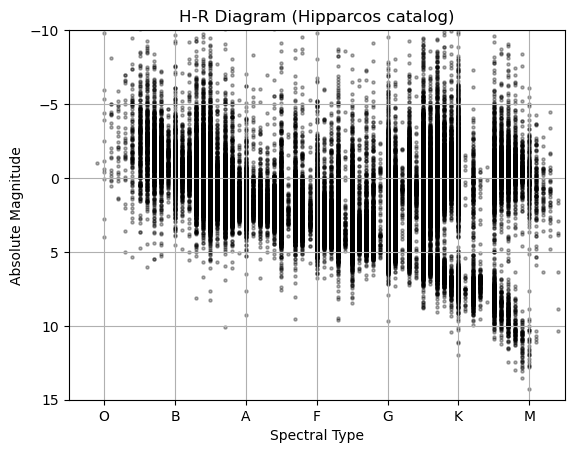

In [121]:
plt.scatter(df_clean['SpType2_numeric'], df_clean['M_V'], s=5, alpha=0.3, c='k')
plt.xlim(0, 70)
plt.ylim(15, -10)
plt.xticks(range(5, 75, 10), labels=['O', 'B', 'A', 'F', 'G', 'K', 'M'])
plt.xlabel('Spectral Type')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram (Hipparcos catalog)')
plt.grid()
plt.show()

**Color Index (B-V) vs. Absolute Magnitude** \
Scatter the `df_clean['B-V']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(-0.5, 2.5).
* Set a `ylim` of `(15, -10).
* Title the x-axis `'Color Index (B-V)'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

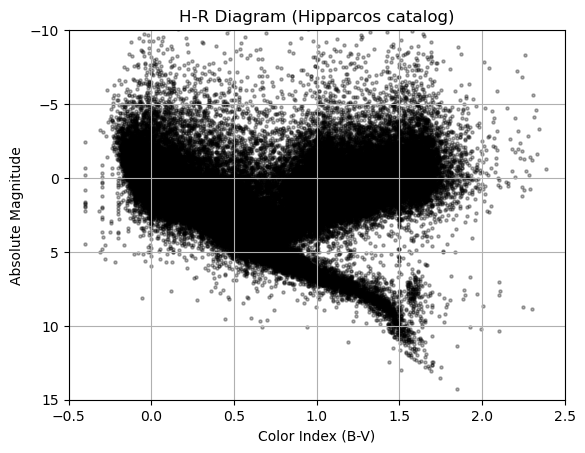

In [123]:
plt.scatter(df_clean['B-V'], df_clean['M_V'], s=5, alpha=0.3, c='k')
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram (Hipparcos catalog)')
plt.grid()
plt.show()

### 6.6 Highlight Luminosity Classes
Great! Finally, we want to difference between our three main luminosity classes:
* Main Sequence (V), aka what our sun is
* Giants (III)
* Supergiants(I)

Run the cell below.

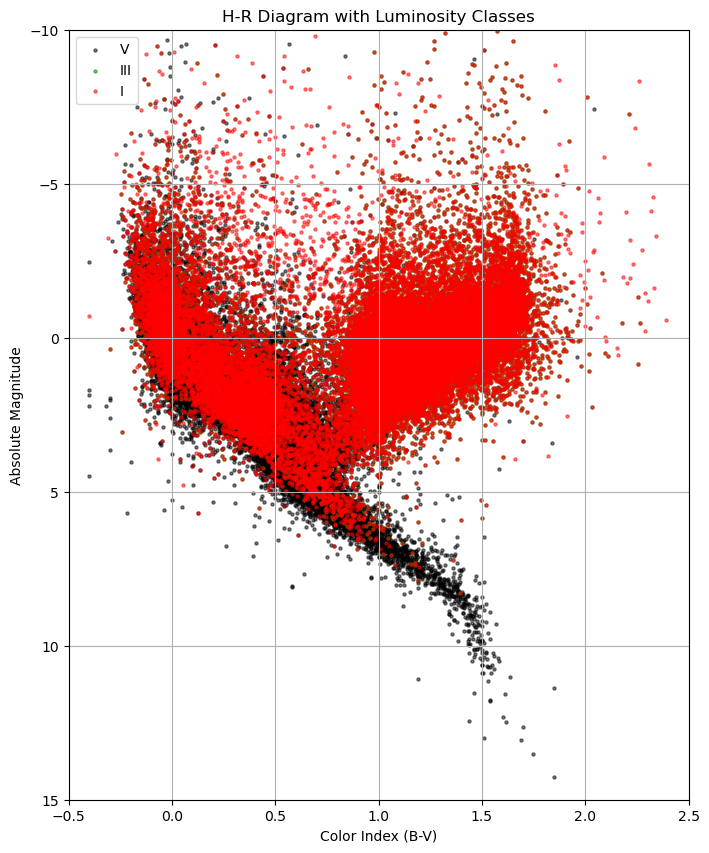

In [125]:
def plot_luminosity_class(df, label, color):
    mask = df['SpType'].str.contains(label, na=False)
    plt.scatter(df[mask]['B-V'], df[mask]['M_V'], s=5, label=label, c=color, alpha=0.5)

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants

plt.legend()
plt.show()

With the example above, now plot the following types **WITH** and then **WITHOUT** the ones above:
* Subdwarfs (VI)
* White dwarfs (VII)
* Subgiants (IV)
* Bright giants (II)

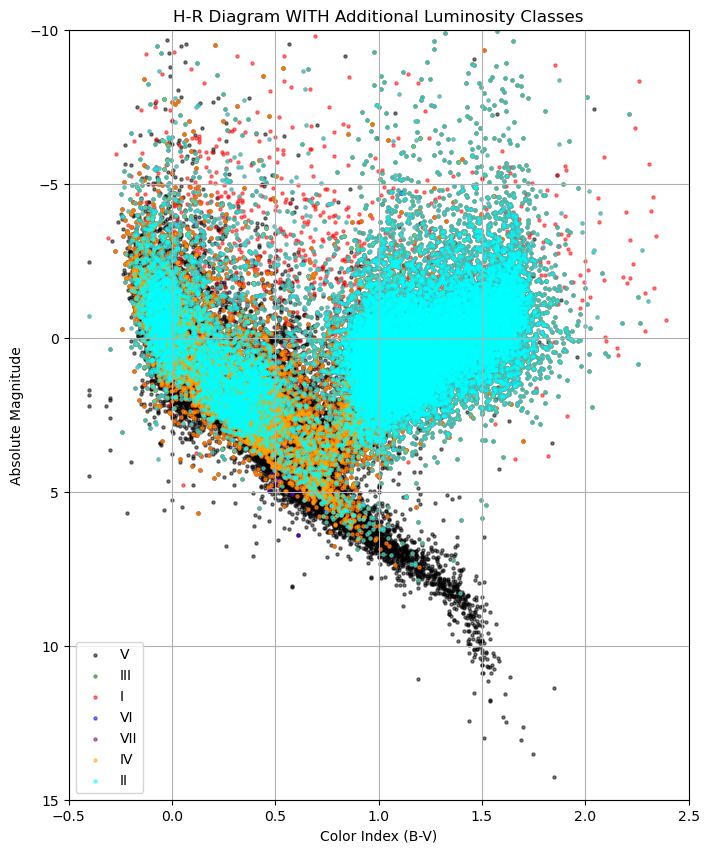

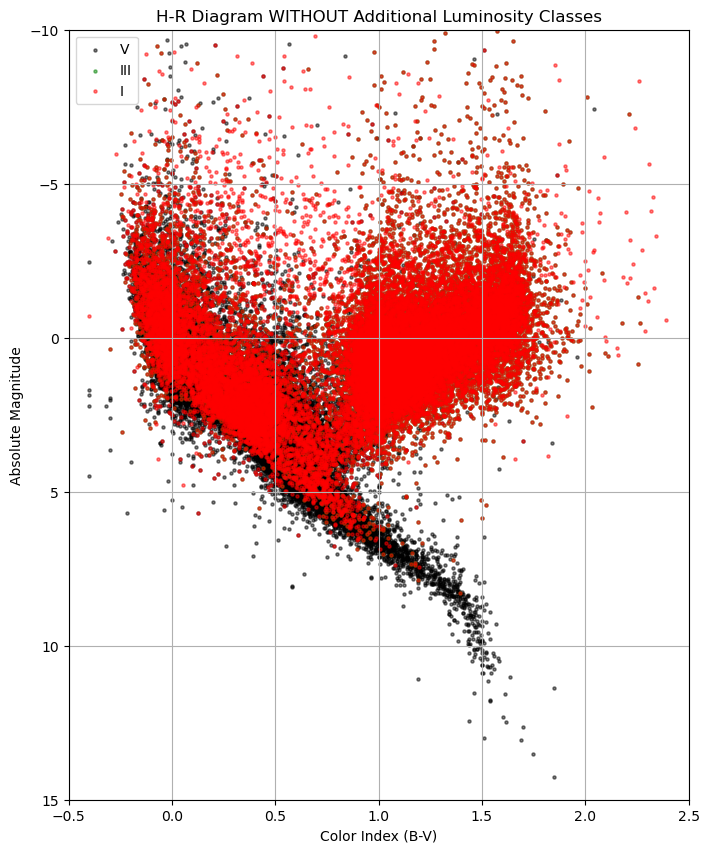

In [127]:
plt.figure(figsize=(8, 10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram WITH Additional Luminosity Classes')

# Original luminosity classes
plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants

# Additional luminosity classes
plot_luminosity_class(df_clean, 'VI', 'blue')  # Subdwarfs
plot_luminosity_class(df_clean, 'VII', 'purple')  # White Dwarfs
plot_luminosity_class(df_clean, 'IV', 'orange')  # Subgiants
plot_luminosity_class(df_clean, 'II', 'cyan')  # Bright Giants

plt.legend()
plt.show()

# Plot H-R diagram WITHOUT additional luminosity classes (only Main Sequence, Giants, Supergiants).
plt.figure(figsize=(8, 10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram WITHOUT Additional Luminosity Classes')

# Original luminosity classes only
plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants

plt.legend()
plt.show()

Submit your FITS file and this notebook to Gradescope!